<a href="https://colab.research.google.com/github/Eng-MIR/DEPI4-CCPA/blob/main/Milestone3_Machine_Learning_Model_Development_and_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Milestone 3: Machine Learning Model Development & Optimization**

**Customer Churn Prediction — IBM Telco Dataset**


Sections:
1. Train / test split + SMOTE
2. Baseline training of 5 classifiers
3. 5-fold stratified cross-validation
4. Confusion matrices + classification reports
5. GridSearchCV tuning (Gradient Boosting & Random Forest)
6. Final comparison + ROC curves


##1. Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.naive_bayes     import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve
)

from imblearn.pipeline       import Pipeline
from imblearn.over_sampling  import SMOTE

##2. Load the cleaned dataset (output of Milestone 1)

In [ ]:
df = pd.read_csv('/content/sample_data/Data/final_top15_selected_features_customer_churn.csv')
print('Loaded shape:', df.shape)
df.head()

Loaded shape: (7043, 16)


,ChargePerService,TotalCharges,tenure,MonthlyCharges,AvgMonthlySpend,Contract_Two year,InternetService_Fiber optic,PaymentMethod_Electronic check,Contract_One year,IsLongTerm,TotalServices,PaperlessBilling_Yes,gender_Male,tenure_group_4-6 Years,Partner_Yes,Churn
0,0.255487,0.001275,0.013889,0.115423,0.004136,0,0,1,0,0,0.125,1,0,0,1,0
1,0.231343,0.215867,0.472222,0.385075,0.032272,0,0,0,1,1,0.375,0,1,0,0,0
2,0.204126,0.010310,0.027778,0.354229,0.019352,0,0,0,0,0,0.375,1,1,0,0,1
3,0.102722,0.210241,0.625000,0.239303,0.022209,0,0,0,1,1,0.375,0,1,0,0,0
4,0.972783,0.015330,0.027778,0.521891,0.029797,0,1,1,0,0,0.125,1,0,0,0,1


##3. Train / test split + SMOTE

Stratified 80/20 split preserves the 73/27 churn ratio in both subsets. SMOTE is applied **only to the training set** so the test set still reflects real-world distribution.

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Before SMOTE:')
print(y_train.value_counts())

Before SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64


In [ ]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('After SMOTE (training set):')
print(y_train_bal.value_counts())
print('\nTest set (unchanged):')
print(y_test.value_counts())
print('\nShapes -> X_train_bal:', X_train_bal.shape, '| X_test:', X_test.shape)

After SMOTE (training set):
Churn
0    4139
1    4139
Name: count, dtype: int64

Test set (unchanged):
Churn
0    1035
1     374
Name: count, dtype: int64

Shapes -> X_train_bal: (8278, 15) | X_test: (1409, 15)


## 4. Baseline models — train and quick metrics

Five classifiers covering linear, ensemble, instance-based, and probabilistic approaches.

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=10000, random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Naive Bayes':         GaussianNB(),
}

In [ ]:
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model':    name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1':       round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':  round(roc_auc_score(y_test, y_proba), 4),
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(results_df.to_string(index=False))

              Model  Accuracy     F1  ROC-AUC
  Gradient Boosting    0.7637 0.6400   0.8392
Logistic Regression    0.7268 0.6107   0.8331
        Naive Bayes    0.6991 0.5970   0.8146
      Random Forest    0.7686 0.5955   0.8120
                KNN    0.7204 0.5791   0.7776


##5. 5-fold Stratified Cross-Validation (SMOTE applied per fold)

Wraps SMOTE inside an `imblearn.Pipeline` so synthetic minority samples never leak into the validation fold.

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, model in models.items():
    pipe = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   model)
    ])

    scores_f1  = cross_val_score(pipe, X_train, y_train, cv=skf,
                                 scoring='f1', n_jobs=-1)
    scores_auc = cross_val_score(pipe, X_train, y_train, cv=skf,
                                 scoring='roc_auc', n_jobs=-1)

    cv_results.append({
        'Model':        name,
        'F1 mean':      round(scores_f1.mean(), 4),
        'F1 std':       round(scores_f1.std(), 4),
        'ROC-AUC mean': round(scores_auc.mean(), 4),
        'ROC-AUC std':  round(scores_auc.std(), 4),
    })

cv_df = pd.DataFrame(cv_results).sort_values('ROC-AUC mean', ascending=False)
print(cv_df.to_string(index=False))

              Model  F1 mean  F1 std  ROC-AUC mean  ROC-AUC std
  Gradient Boosting   0.6247  0.0160        0.8389       0.0123
Logistic Regression   0.6236  0.0122        0.8388       0.0118
      Random Forest   0.5882  0.0144        0.8195       0.0101
        Naive Bayes   0.5891  0.0127        0.8179       0.0104
                KNN   0.5752  0.0144        0.7759       0.0126


##6. Confusion matrices + classification reports

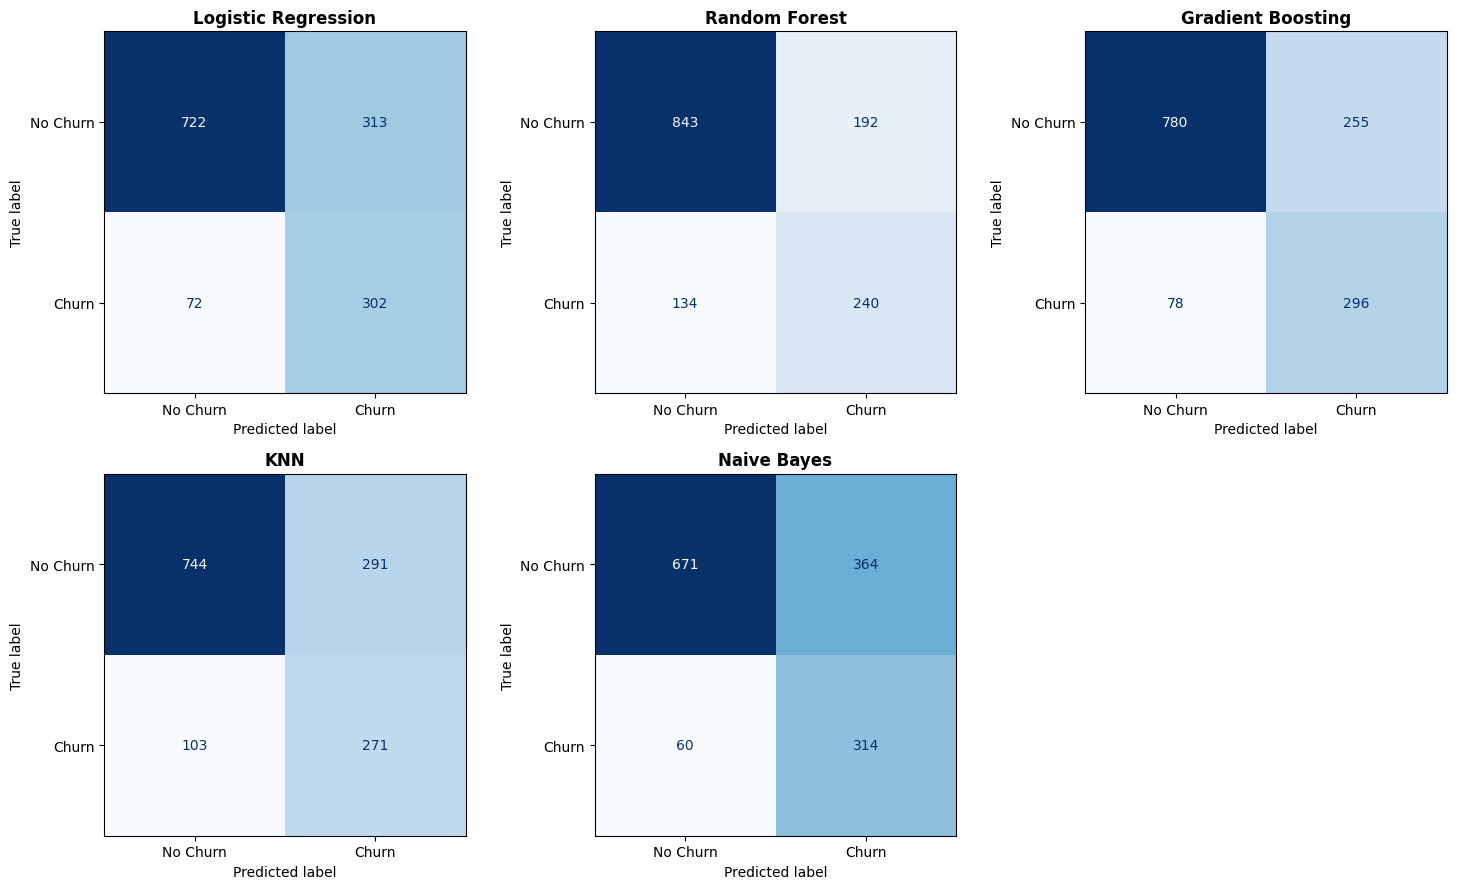

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Churn', 'Churn'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(name, fontsize=12, fontweight='bold')
    axes[i].grid(False)

for j in range(len(trained_models), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
print('=' * 70)
print('CLASSIFICATION REPORTS')
print('=' * 70)
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    print(f'\n--- {name} ---')
    print(classification_report(y_test, y_pred,
                                target_names=['No Churn', 'Churn'],
                                digits=3))

CLASSIFICATION REPORTS

--- Logistic Regression ---
              precision    recall  f1-score   support

    No Churn      0.909     0.698     0.790      1035
       Churn      0.491     0.807     0.611       374

    accuracy                          0.727      1409
   macro avg      0.700     0.753     0.700      1409
weighted avg      0.798     0.727     0.742      1409


--- Random Forest ---
              precision    recall  f1-score   support

    No Churn      0.863     0.814     0.838      1035
       Churn      0.556     0.642     0.596       374

    accuracy                          0.769      1409
   macro avg      0.709     0.728     0.717      1409
weighted avg      0.781     0.769     0.774      1409


--- Gradient Boosting ---
              precision    recall  f1-score   support

    No Churn      0.909     0.754     0.824      1035
       Churn      0.537     0.791     0.640       374

    accuracy                          0.764      1409
   macro avg      0.723   

##7. Hyperparameter tuning — GridSearchCV

Tune the two strongest baselines: Gradient Boosting and Random Forest.

###7.1 Gradient Boosting

In [ ]:
gb_pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   GradientBoostingClassifier(random_state=42))
])

gb_param_grid = {
    'clf__n_estimators':  [100, 200],
    'clf__learning_rate': [0.05, 0.1],
    'clf__max_depth':     [3, 5],
}

gb_grid = GridSearchCV(gb_pipe, gb_param_grid, cv=5,
                       scoring='roc_auc', n_jobs=-1, verbose=1)
gb_grid.fit(X_train, y_train)

print('--- Gradient Boosting tuned ---')
print('Best params:', gb_grid.best_params_)
print('Best CV ROC-AUC:', round(gb_grid.best_score_, 4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
--- Gradient Boosting tuned ---
Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100}
Best CV ROC-AUC: 0.8394


### 7.2 Random Forest

In [ ]:
rf_pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_param_grid = {
    'clf__n_estimators':      [100, 200],
    'clf__max_depth':         [None, 20],
    'clf__min_samples_split': [2, 5],
}

rf_grid = GridSearchCV(rf_pipe, rf_param_grid, cv=5,
                       scoring='roc_auc', n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print('--- Random Forest tuned ---')
print('Best params:', rf_grid.best_params_)
print('Best CV ROC-AUC:', round(rf_grid.best_score_, 4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
--- Random Forest tuned ---
Best params: {'clf__max_depth': 20, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Best CV ROC-AUC: 0.8209


##8. Final comparison — baseline + tuned, on the held-out test set

In [ ]:
tuned_models = {
    'Gradient Boosting (tuned)': gb_grid.best_estimator_,
    'Random Forest (tuned)':     rf_grid.best_estimator_,
}
all_models = {**trained_models, **tuned_models}

final_results = []
for name, model in all_models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    final_results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4),
    })

final_df = (pd.DataFrame(final_results)
              .sort_values('ROC-AUC', ascending=False)
              .reset_index(drop=True))
print('=' * 80)
print('FINAL MODEL COMPARISON (sorted by ROC-AUC)')
print('=' * 80)
print(final_df.to_string(index=False))

FINAL MODEL COMPARISON (sorted by ROC-AUC)
                    Model  Accuracy  Precision  Recall     F1  ROC-AUC
Gradient Boosting (tuned)    0.7466     0.5145  0.8075 0.6285   0.8393
        Gradient Boosting    0.7637     0.5372  0.7914 0.6400   0.8392
      Logistic Regression    0.7268     0.4911  0.8075 0.6107   0.8331
    Random Forest (tuned)    0.7700     0.5556  0.6684 0.6068   0.8218
              Naive Bayes    0.6991     0.4631  0.8396 0.5970   0.8146
            Random Forest    0.7686     0.5556  0.6417 0.5955   0.8120
                      KNN    0.7204     0.4822  0.7246 0.5791   0.7776


### 6.1 ROC curves — all models on one chart

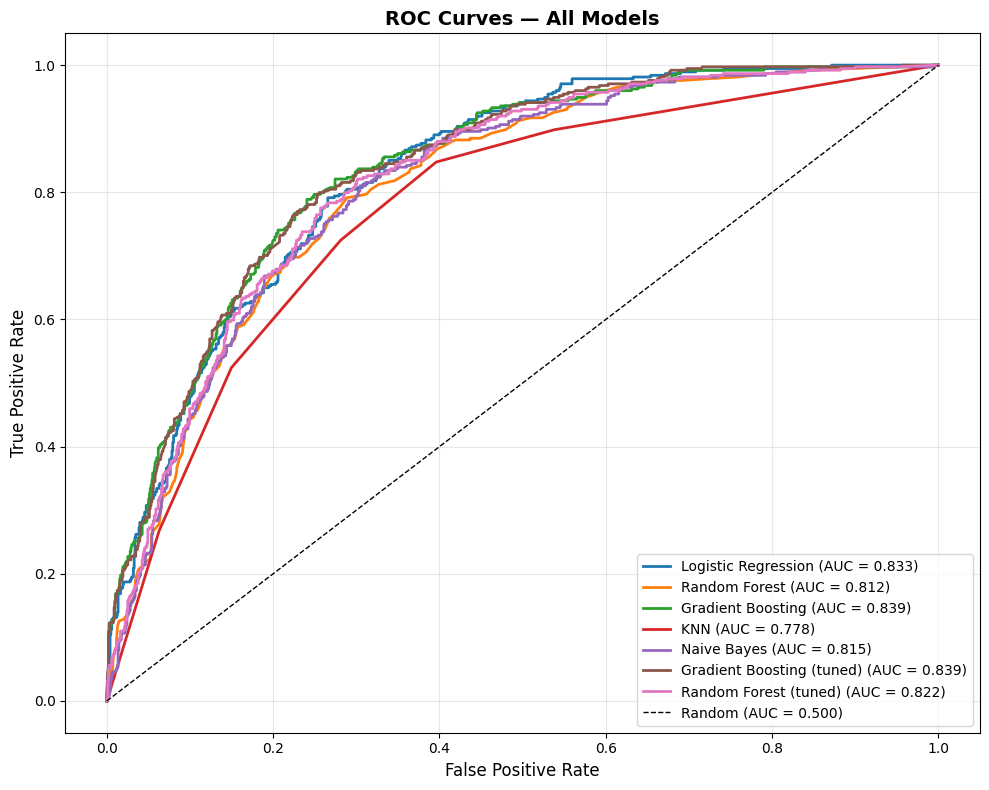

In [ ]:
plt.figure(figsize=(10, 8))
for name, model in all_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 7. Pick the winner — by F1

ROC-AUC ranks the untuned GB at the top, but tuned GB has higher F1 and recall on the churn class — which matter more for a retention use case.

In [ ]:
final_by_f1 = final_df.sort_values('F1', ascending=False).reset_index(drop=True)
winner_name = final_by_f1.iloc[0]['Model']
winner_auc  = final_by_f1.iloc[0]['ROC-AUC']
winner_f1   = final_by_f1.iloc[0]['F1']
print(f'Best model (by F1): {winner_name}')
print(f'  Test ROC-AUC = {winner_auc} | F1 = {winner_f1}')

best_model = all_models[winner_name]

Best model (by F1): Gradient Boosting
  Test ROC-AUC = 0.8392 | F1 = 0.64


In [ ]:
## 8. Save the winning model + its metadata
#
# We save TWO files that work as a pair:
#   1. The model itself  -> .joblib  (the actual "brain", saved with joblib)
#   2. Info about it      -> .json    (name, scores, settings, saved with json)

import joblib
import json
from datetime import datetime

# ---- 1. Save the actual model with joblib ----
model_filename = 'best_churn_model.joblib'
joblib.dump(best_model, model_filename)
print(f'Model saved to: {model_filename}')

# ---- 2. Save the metadata (the simple facts) to JSON ----
# Pull this winner's row of scores from the final results table
winner_row = final_df[final_df['Model'] == winner_name].iloc[0]

model_info = {
    'model_name':   winner_name,
    'saved_at':     datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'metrics': {
        'accuracy':  float(winner_row['Accuracy']),
        'precision': float(winner_row['Precision']),
        'recall':    float(winner_row['Recall']),
        'f1':        float(winner_row['F1']),
        'roc_auc':   float(winner_row['ROC-AUC']),
    },
    'selected_by':   'F1 score',
    'feature_names': list(X.columns),
}   # <-- close the metrics dict AND the model_info dict

# ---- write the metadata to a JSON file ----
info_filename = 'best_churn_model_info.json'
with open(info_filename, 'w') as f:
    json.dump(model_info, f, indent=2)
print(f'Metadata saved to: {info_filename}')

# ---- confirm ----
print('\nSaved metadata:')
print(json.dumps(model_info, indent=2))

Model saved to: best_churn_model.joblib
Metadata saved to: best_churn_model_info.json

Saved metadata:
{
  "model_name": "Gradient Boosting",
  "saved_at": "2026-05-21 07:38:50",
  "metrics": {
    "accuracy": 0.7637,
    "precision": 0.5372,
    "recall": 0.7914,
    "f1": 0.64,
    "roc_auc": 0.8392
  },
  "selected_by": "F1 score",
  "feature_names": [
    "ChargePerService",
    "TotalCharges",
    "tenure",
    "MonthlyCharges",
    "AvgMonthlySpend",
    "Contract_Two year",
    "InternetService_Fiber optic",
    "PaymentMethod_Electronic check",
    "Contract_One year",
    "IsLongTerm",
    "TotalServices",
    "PaperlessBilling_Yes",
    "gender_Male",
    "tenure_group_4-6 Years",
    "Partner_Yes"
  ]
}
